## XGBoost로 평점-매출 분석하기

In [87]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import math

In [89]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [91]:
df = pd.read_csv('review-vc_sales-by_collection_category_20250508_v2.csv')

In [93]:
df_gtmf = df[df['main_collection'].str.contains('GTMF', na=False)]

In [95]:
df_gtmf['main_collection'].nunique()
df_gtmf['main_collection'].value_counts()

main_collection
12in Green Tea MF (+ GTMF)    57
8in Green Tea MF (+ GTMF)     56
6in Green Tea MF (+ GTMF)     56
10in Green Tea MF (+ GTMF)    56
5in Green Tea MF (+ GTMF)     15
Name: count, dtype: int64

In [97]:
filtered_df = df_gtmf[['main_collection','written_avg_rating','sales_amount']].dropna()

In [99]:
filtered_df

,main_collection,written_avg_rating,sales_amount
35,8in Green Tea MF (+ GTMF),3.476190,565753.62
43,6in Green Tea MF (+ GTMF),3.333333,594109.45
56,12in Green Tea MF (+ GTMF),3.210000,2363947.51
66,10in Green Tea MF (+ GTMF),3.944444,474478.42
453,8in Green Tea MF (+ GTMF),2.818182,438735.75
...,...,...,...
23463,5in Green Tea MF (+ GTMF),3.071429,248747.90
23471,12in Green Tea MF (+ GTMF),3.344828,3084474.16
23472,12in Green Tea MF (+ GTMF),2.846154,0.00
23484,10in Green Tea MF (+ GTMF),3.155556,2485565.90


In [101]:
collections = filtered_df['main_collection'].unique()

In [103]:
collections

array(['8in Green Tea MF (+ GTMF)', '6in Green Tea MF (+ GTMF)',
       '12in Green Tea MF (+ GTMF)', '10in Green Tea MF (+ GTMF)',
       '5in Green Tea MF (+ GTMF)'], dtype=object)

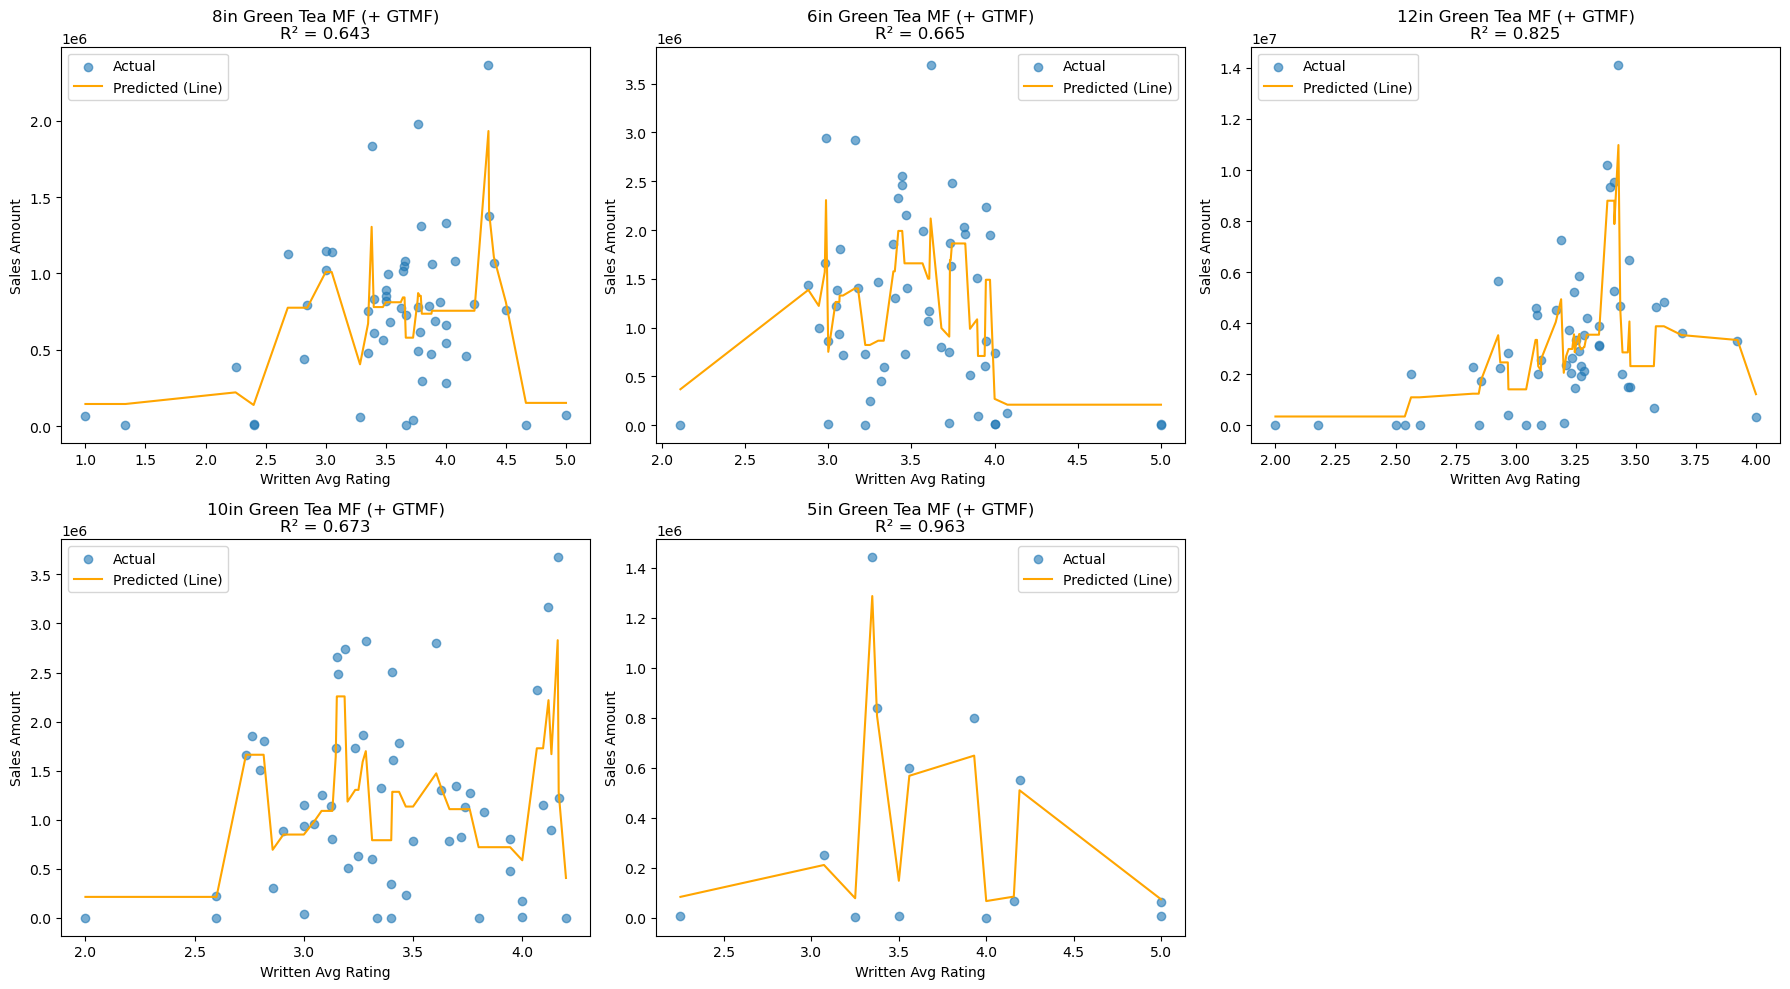

In [77]:
# 시각화 레이아웃 설정 (n개의 서브플롯 자동 배치)
n = len(collections)
cols = 3
rows = math.ceil(n / cols)
fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axs = axs.flatten()

# 각 컬렉션별 XGBoost 학습 및 시각화
for idx, collection in enumerate(collections):
    sub_df = filtered_df[filtered_df['main_collection'] == collection]
    X = sub_df[['written_avg_rating']]
    y = sub_df['sales_amount']
    
    model = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1)
    model.fit(X, y)
    y_pred = model.predict(X)
    r2_val = r2_score(y, y_pred)

    # X를 기준으로 정렬
    sorted_idx = X['written_avg_rating'].argsort()
    X_sorted = X.iloc[sorted_idx]
    y_sorted = y.iloc[sorted_idx]
    y_pred_sorted = y_pred[sorted_idx]

    axs[idx].scatter(X, y, label='Actual', alpha=0.6)
    #axs[idx].scatter(X, y_pred, label='Predicted', alpha=0.6)
    axs[idx].plot(X_sorted, y_pred_sorted, label='Predicted (Line)', color='orange')

    
    axs[idx].set_title(f"{collection}\nR² = {r2_val:.3f}")
    axs[idx].set_xlabel("Written Avg Rating")
    axs[idx].set_ylabel("Sales Amount")
    axs[idx].legend()

# 나머지 빈 subplot 숨기기
for j in range(idx + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

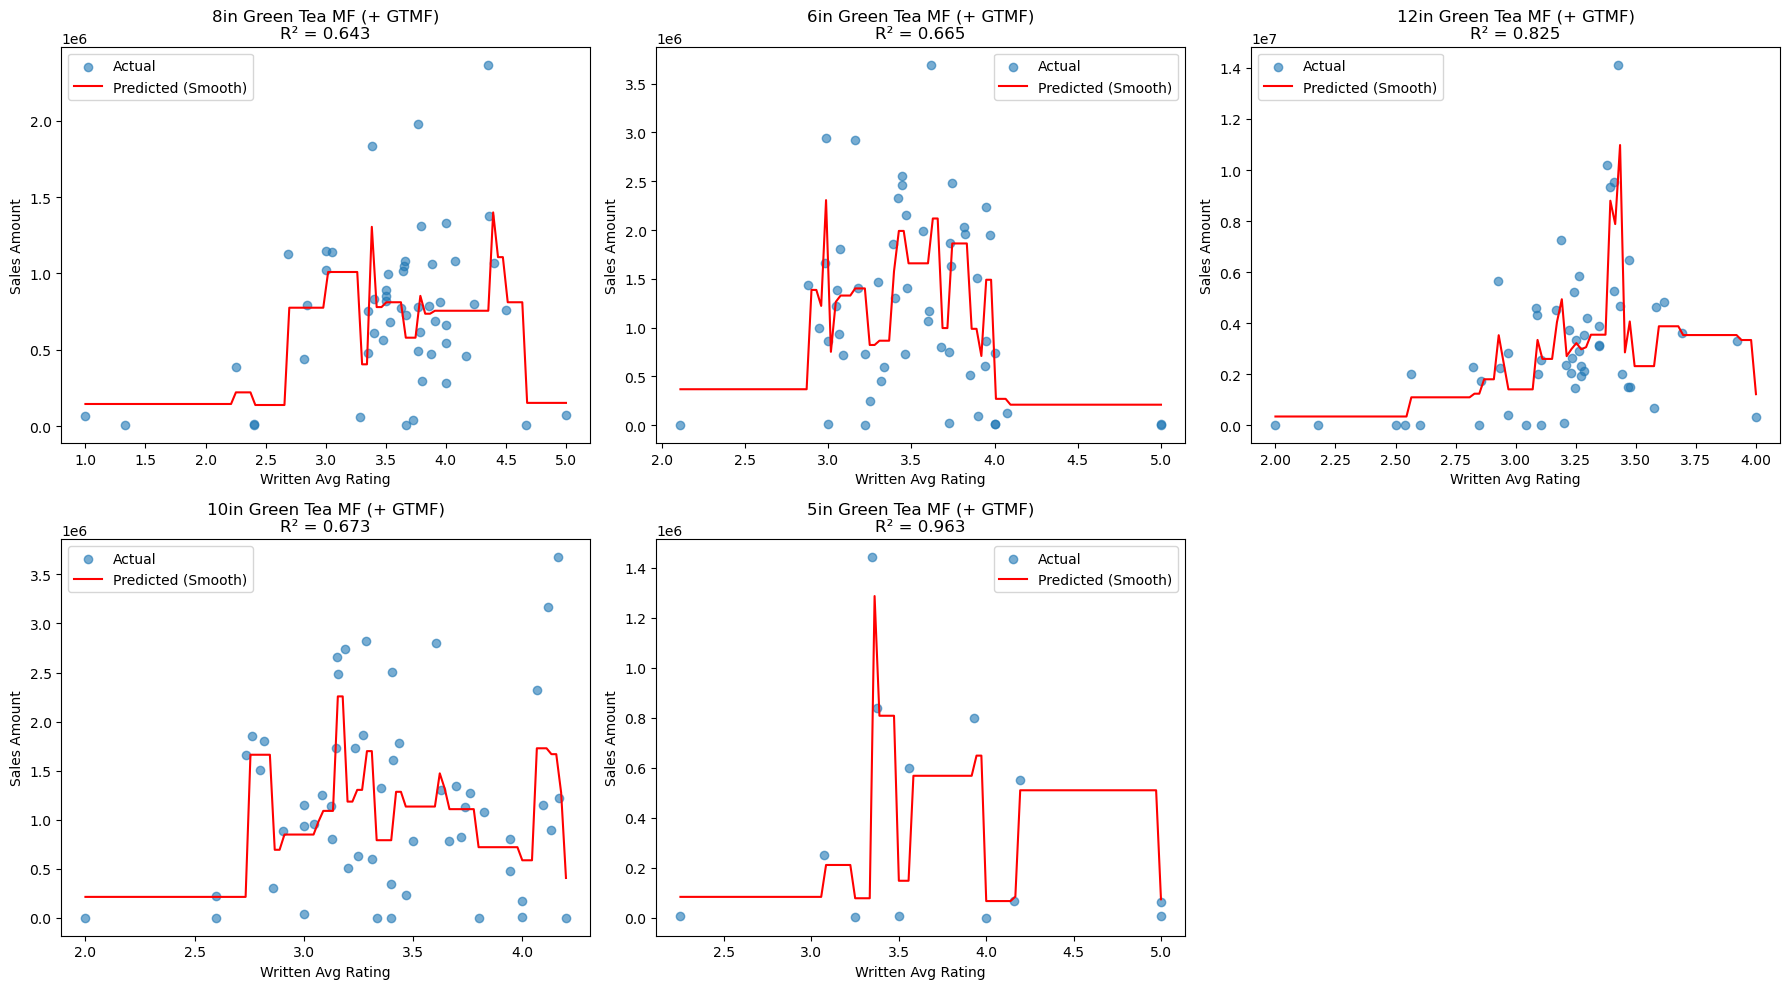

In [107]:
# 시각화 레이아웃 설정 (n개의 서브플롯 자동 배치)
n = len(collections)
cols = 3
rows = math.ceil(n / cols)
fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axs = axs.flatten()

# 각 컬렉션별로 학습 및 시각화
for idx, collection in enumerate(collections):
    sub_df = filtered_df[filtered_df['main_collection'] == collection]
    X = sub_df[['written_avg_rating']]
    y = sub_df['sales_amount']

    model = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1)
    model.fit(X, y)
    y_pred = model.predict(X)
    r2_val = r2_score(y, y_pred)

    # 평점 구간을 세밀히 나눠 부드러운 선을 위한 X값 생성
    x_range = np.linspace(X['written_avg_rating'].min(), X['written_avg_rating'].max(), 100)
    x_range_df = pd.DataFrame({'written_avg_rating': x_range})
    y_line = model.predict(x_range_df)

    # 실제 점과 부드러운 예측선 시각화
    axs[idx].scatter(X, y, label='Actual', alpha=0.6)
    axs[idx].plot(x_range, y_line, label='Predicted (Smooth)', color='red')
    axs[idx].set_title(f"{collection}\nR² = {r2_val:.3f}")
    axs[idx].set_xlabel("Written Avg Rating")
    axs[idx].set_ylabel("Sales Amount")
    axs[idx].legend()

# 남은 subplot 비우기
for j in range(idx + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()
